In [1]:
using Distributed
procs_to_use = 1
if nprocs() <= procs_to_use
    addprocs(procs_to_use-nprocs())
end
;

In [10]:
# using Logging: global_logger
# using TerminalLoggers: TerminalLogger
# global_logger(TerminalLogger())

@everywhere begin
    include("../misc/helper_functions.jl")
    include("../misc/compute_size_temperature.jl")
    include("define_CaF_structure.jl")
    include("define_blueMOTconveyor_params.jl")
    include("define_blueMOT_prob.jl")
end
;

# 1+1 CaF MOT

In [6]:
n_iterations = 2
n_trajectories = 4
n_trajectories_diffusion = 5000
n_times = 30
diffusion_t_end = 5e-6
diffusion_τ_total = 5e-6

(diffusions, diffusion_errors, diffusions_over_time) = compute_diffusion_iteratively(
    prob, prob_func_CaF!, prob_diffusion, prob_func_diffusion_CaF!, 
    n_iterations, n_trajectories, n_trajectories_diffusion, n_times, diffusion_t_end, diffusion_τ_total
)
;

Progress: 100%|█████████████████████████████████████████| Time: 0:01:08
Progress: 100%|█████████████████████████████████████████| Time: 0:02:40m14m
Progress: 100%|█████████████████████████████████████████| Time: 0:02:21m
Progress: 100%|█████████████████████████████████████████| Time: 0:00:37
Progress: 100%|█████████████████████████████████████████| Time: 0:02:10
Progress: 100%|█████████████████████████████████████████| Time: 0:02:08


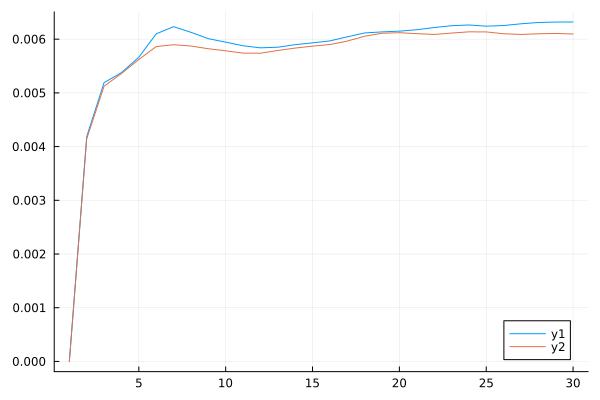

In [7]:
plot(diffusions_over_time[1,2,:,:]')

In [17]:
diffusion = diffusions[1,:,end]
@everywhere prob.p.diffusion_constant = $[diffusion[1], diffusion[1], diffusion[2]]
@time sols = distributed_solve(20, prob, prob_func_CaF!, scan_nothing, [0])
;

Progress: 100%|█████████████████████████████████████████| Time: 0:05:59


382.545752 seconds (8.78 M allocations: 1020.432 MiB, 0.59% gc time, 1 lock conflict, 0.04% compilation time)


In [22]:
xs = [x.(sols[1][i].u) for i ∈ eachindex(sols[1])][1:30:end]
ys = [y.(sols[1][i].u) for i ∈ eachindex(sols[1])][1:30:end]
zs = [z.(sols[1][i].u) for i ∈ eachindex(sols[1])][1:30:end]
;

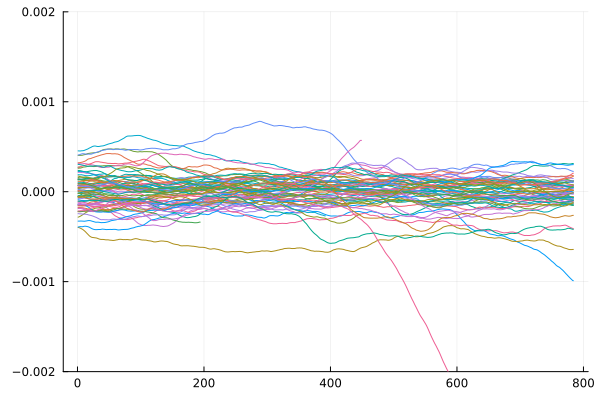

In [23]:
plot(zs, legend=nothing, ylim=(-0.002,+0.002))

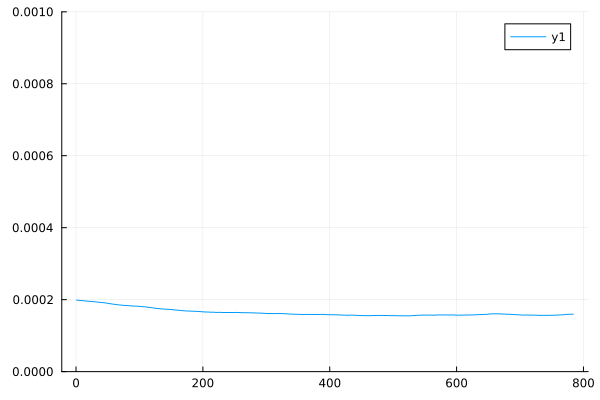

In [24]:
σs = σ_vs_time(sols[1])
plot(σs, ylim=(0, 1000e-6))

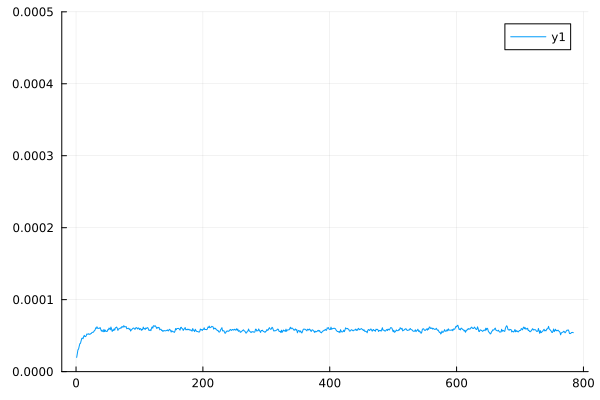

In [25]:
Ts = T_vs_time(sols[1])
plot(Ts, ylim=(0, 0.0005))

# 1+2 MOT CaF

In [5]:
@everywhere begin
    include("../misc/helper_functions.jl")
    include("../misc/compute_size_temperature.jl")
    include("define_CaF_structure.jl")
    include("define_blueMOTconveyor_params.jl")
    include("define_blueMOT_prob.jl")
end
;

In [ ]:
n_iterations = 2
n_trajectories = 4
n_trajectories_diffusion = 5000
n_times = 30
diffusion_t_end = 5e-6
diffusion_τ_total = 5e-6

(diffusions, diffusion_errors, diffusions_over_time) = compute_diffusion_iteratively(
    prob, prob_func_CaF!, prob_diffusion, prob_func_diffusion_CaF!, 
    n_iterations, n_trajectories, n_trajectories_diffusion, n_times, diffusion_t_end, diffusion_τ_total
)
;